# Gaussian Process Simulation of Photonic Circuits

This notebook shows how to chain the `vector_fitting/z_domain` and `stochastic/gaussian_process`
modules together to perform a full stochastic time-domain simulation of a photonic circuit.

The pipeline has four stages:

1. **Circuit → S-parameters** — use SAX to assemble a circuit and evaluate its scattering matrix
   over a frequency grid.
2. **S-parameters → pole-residue model** — use `vector_fitting_discrete` to fit a compact
   rational model in the z-domain.
3. **Pole-residue → state-space → impulse response** — convert to ABCD matrices and extract
   the discrete-time impulse response by running unit impulses through the state-space system.
4. **Impulse response → Gaussian process** — use `gaussian_process_response` (the Papoulis
   equations) to propagate the mean *and* covariance of a Gaussian random process through
   the circuit.

**Physical scenario:** a ring resonator driven by a noisy coherent laser at port 0.  
We track how the coherent mean signal and the amplitude noise (covariance) evolve together
as the light circulates in the ring.

In [1]:
import sys
import numpy as np
import jax
import jax.numpy as jnp
from jax import config

config.update("jax_enable_x64", True)   # need 64-bit for accurate vector fitting

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import sax
from scipy.constants import speed_of_light

# Circuit components
from simphony.libraries.old_ideal import coupler, waveguide
from simphony.utils import dict_to_matrix

# z-domain vector fitting
from simphony.time_domain.vector_fitting.z_domain import (
    vector_fitting_discrete,
    pole_residue_response_discrete,
    state_space_discrete,
    state_space_response_discrete,
)

# Gaussian process stochastic simulation
from simphony.time_domain.stochastic.gaussian_process import (
    gaussian_process_response,
    white_noise_covariance,
    covariance_blocks_to_matrix,
)

print("Imports OK")

Imports OK


## 1. Circuit Setup: Ring Resonator

We build a 2-port ring resonator using two ideal components:

- **`coupler`** — a 50/50 directional coupler (the bus-ring coupling junction).
- **`waveguide`** — a straight waveguide that closes the ring loop.

The coupler has ports `o0`, `o1` (bus) and `o2`, `o3` (ring side).  
Connecting `o2 → waveguide → o3` completes the ring, leaving `o0` and `o1` as the
external ports.

```
              ┌─ waveguide (77 µm) ─┐
  o0 ──┤ coupler ├── o1
              └─────────────────────┘
```

In [2]:
netlist = {
    "instances": {"wg": "waveguide", "dc": "dc"},
    "connections": {"dc,o2": "wg,o0", "dc,o3": "wg,o1"},
    "ports": {"o0": "dc,o0", "o1": "dc,o1"},
}
circuit, _ = sax.circuit(
    netlist=netlist,
    models={"waveguide": waveguide, "dc": coupler},
)

# --- Frequency grid -----------------------------------------------------------
wvl_um = np.linspace(1.50, 1.60, 400)          # wavelength in µm
freq   = speed_of_light / (wvl_um * 1e-6)      # frequency in Hz
f_center         = float(np.mean(freq))         # baseband center
sampling_frequency = 1e14                       # 100 THz  (Nyquist window)

# --- S-parameters (shape: N_freq × 2 × 2) ------------------------------------
s_raw = circuit(wl=wvl_um, wg={"length": 77.0, "loss": 100})
S = jnp.array(np.asarray(dict_to_matrix(s_raw)))

print(f"S matrix shape          : {S.shape}")
print(f"Frequency range         : {freq[-1]/1e12:.1f} – {freq[0]/1e12:.1f} THz")
print(f"Center frequency        : {f_center/1e12:.2f} THz")
print(f"Sampling frequency (Fs) : {sampling_frequency/1e12:.0f} THz")

S matrix shape          : (400, 2, 2)
Frequency range         : 187.4 – 199.9 THz
Center frequency        : 193.48 THz
Sampling frequency (Fs) : 100 THz


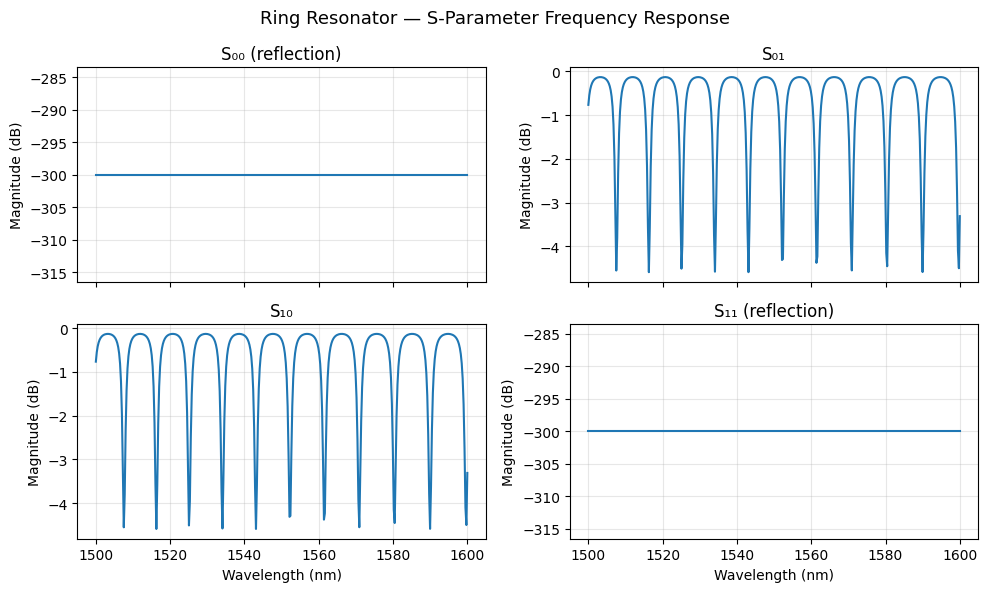

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
labels = [["S₀₀ (reflection)", "S₀₁"], ["S₁₀", "S₁₁ (reflection)"]]

wvl_nm = wvl_um * 1e3  # nm for readability

for i in range(2):
    for j in range(2):
        ax = axes[i, j]
        mag_dB = 20 * np.log10(np.abs(np.asarray(S[:, i, j])) + 1e-15)
        ax.plot(wvl_nm, mag_dB, linewidth=1.5)
        ax.set_title(labels[i][j])
        ax.set_ylabel("Magnitude (dB)")
        ax.grid(True, alpha=0.3)
        if i == 1:
            ax.set_xlabel("Wavelength (nm)")

fig.suptitle("Ring Resonator — S-Parameter Frequency Response", fontsize=13)
plt.tight_layout()
plt.show()

## 2. Fitting a Pole-Residue Model (Vector Fitting)

`vector_fitting_discrete` iteratively relocates poles in the z-plane to minimize the
least-squares error between the pole-residue model and the measured S-matrix:

$$H(z) = D + \sum_{k=1}^{r} \frac{c_k}{z - p_k}$$

where $p_k$ are the **poles** (must lie inside the unit circle for stability),  
$c_k$ are the **residues** (shape `(r, q, m)`), and $D$ is the **feedthrough** matrix.

The result is a compact digital IIR filter description of the ring resonator.

In [4]:
model_order = 20
freq_jnp    = jnp.array(freq)

poles, residues, feedthrough, fit_mse = vector_fitting_discrete(
    model_order, S, freq_jnp, f_center, sampling_frequency
)

print(f"Poles shape    : {poles.shape}")
print(f"Residues shape : {residues.shape}  (r × q × m)")
print(f"Feedthrough    : {feedthrough.shape}")
print(f"Fit MSE        : {fit_mse:.3e}")
print(f"All poles stable (|p| < 1): {bool(jnp.all(jnp.abs(poles) < 1.0))}")

Poles shape    : (20,)
Residues shape : (20, 2, 2)  (r × q × m)
Feedthrough    : (2, 2)
Fit MSE        : 6.185e-22
All poles stable (|p| < 1): True


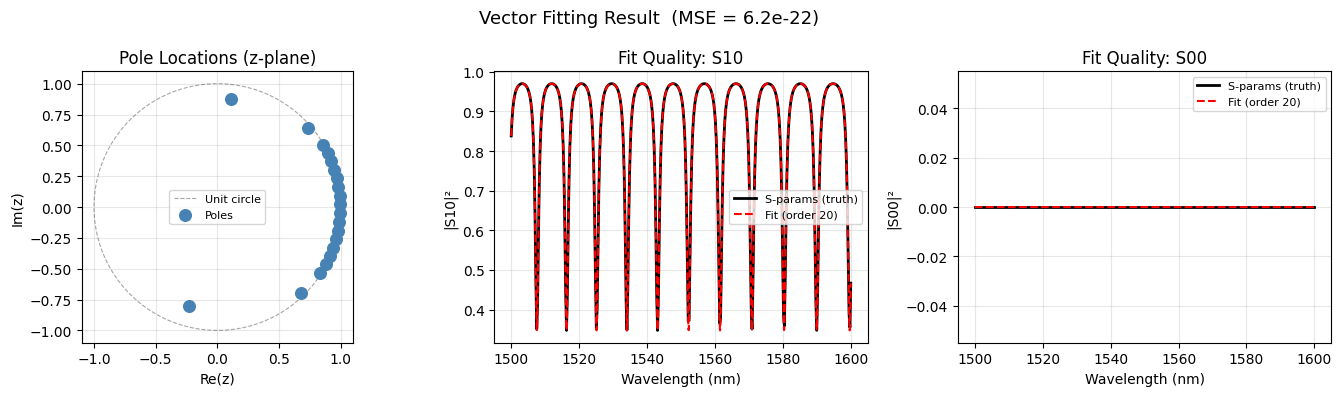

In [5]:
# Evaluate the fitted model on a dense frequency grid
f_dense = jnp.linspace(float(freq[0]), float(freq[-1]), 2000)
S_fit   = pole_residue_response_discrete(
    f_dense, f_center, sampling_frequency, poles, residues, feedthrough
)

# Wavelength from dense frequency (decreasing)
wvl_dense_nm = speed_of_light / np.asarray(f_dense) * 1e9

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# --- Pole locations in z-plane ---
ax = axes[0]
theta = np.linspace(0, 2 * np.pi, 500)
ax.plot(np.cos(theta), np.sin(theta), "k--", alpha=0.35, linewidth=0.8, label="Unit circle")
ax.scatter(np.asarray(poles).real, np.asarray(poles).imag,
           c="steelblue", s=70, zorder=3, label="Poles")
ax.set_aspect("equal")
ax.set_xlabel("Re(z)")
ax.set_ylabel("Im(z)")
ax.set_title("Pole Locations (z-plane)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# --- S₁₀ fit quality ---
for ax_idx, (i, j) in enumerate([(1, 0), (0, 0)], start=1):
    ax = axes[ax_idx]
    ax.plot(wvl_nm, np.abs(np.asarray(S[:, i, j])) ** 2,
            "k", linewidth=2, label="S-params (truth)", zorder=2)
    ax.plot(wvl_dense_nm, np.abs(np.asarray(S_fit[:, i, j])) ** 2,
            "r--", linewidth=1.5, label=f"Fit (order {model_order})", zorder=3)
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel(f"|S{i}{j}|²")
    ax.set_title(f"Fit Quality: S{i}{j}")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle(f"Vector Fitting Result  (MSE = {fit_mse:.1e})", fontsize=13)
plt.tight_layout()
plt.show()

## 3. State-Space Realization

`state_space_discrete` converts the pole-residue model into standard ABCD form:

$$
x[n+1] = A\, x[n] + B\, u[n], \qquad y[n] = C\, x[n] + D\, u[n]
$$

- **A** `(r·m × r·m)` — block-diagonal with replicated poles; maps the state to itself.
- **B** `(r·m × m)` — canonical input selector; injects $u[n]$ into each pole's states.
- **C** `(q × r·m)` — residue matrix; reads out the pole contributions to $y[n]$.
- **D** `(q × m)` — feedthrough; the instantaneous input-to-output path.

The state dimension is `r·m = 20 poles × 2 inputs = 40`.

In [6]:
A, B, C, D = state_space_discrete(poles, residues, feedthrough)

print("State-space matrices:")
print(f"  A  {A.shape}   state transition")
print(f"  B  {B.shape}   input → state")
print(f"  C  {C.shape}   state → output")
print(f"  D  {D.shape}   direct feedthrough")

# Stability check: all eigenvalues of A inside the unit circle
eigs = jnp.linalg.eigvals(A)
print(f"\nMax |eig(A)| = {float(jnp.max(jnp.abs(eigs))):.6f}  (must be < 1 for stability)")

State-space matrices:
  A  (40, 40)   state transition
  B  (40, 2)   input → state
  C  (2, 40)   state → output
  D  (2, 2)   direct feedthrough

Max |eig(A)| = 0.995029  (must be < 1 for stability)


## 4. Discrete-Time Impulse Response

The impulse response $h[k]$ is a `(K × q × m)` tensor where
$h[k,\, i,\, j]$ is the field amplitude arriving at output port $i$ at time step $k$
due to a unit impulse injected into input port $j$ at $k=0$.

We compute it by driving the state-space system with a unit-impulse input at each
port separately and stacking the results:

$$h[k] = C A^{k-1} B \;(k \geq 1), \quad h[0] = D$$

This is exactly what `state_space_response_discrete` does when given $u[0] = e_j$
(the $j$-th standard basis vector).

In [7]:
K_ir    = 200        # impulse response taps to compute
n_ports = 2
dt      = 1.0 / sampling_frequency   # seconds per sample
t_ir_ps = np.arange(K_ir) * dt * 1e12   # time axis in picoseconds

h_cols = []
for port_in in range(n_ports):
    u_impulse = jnp.zeros((K_ir, n_ports), dtype=complex)
    u_impulse = u_impulse.at[0, port_in].set(1.0)
    y_col, _ = state_space_response_discrete(A, B, C, D, u_impulse)
    h_cols.append(y_col)           # (K_ir, n_ports)

# h[k, output_port, input_port]
h = jnp.stack(h_cols, axis=2)     # (K_ir, 2, 2)

print(f"Impulse response tensor h  : {h.shape}   (K × q × m)")
print(f"Time resolution            : {dt*1e12:.2f} ps/sample")
print(f"Total span                 : {t_ir_ps[-1]:.1f} ps")

Impulse response tensor h  : (200, 2, 2)   (K × q × m)
Time resolution            : 0.01 ps/sample
Total span                 : 2.0 ps


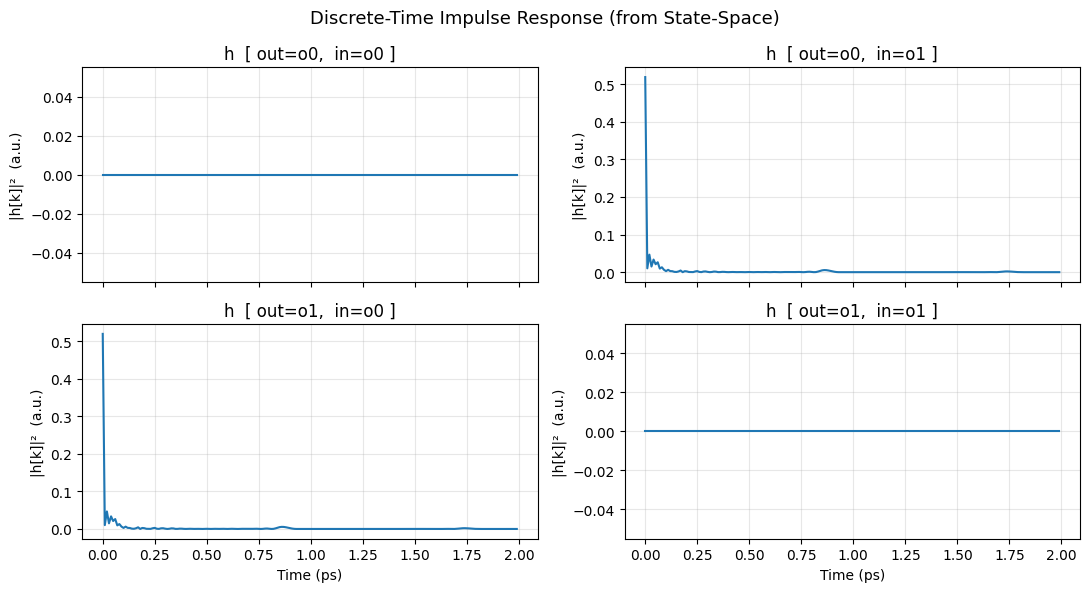

Parseval check  ‖h[:,1,0]‖²=0.8086  vs  mean|S₁₀|²=0.8609


In [8]:
port_names = ["o0", "o1"]

fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharex=True)
for i in range(2):
    for j in range(2):
        ax = axes[i, j]
        ax.plot(t_ir_ps, np.abs(np.asarray(h[:, i, j])) ** 2, linewidth=1.5)
        ax.set_title(f"h  [ out={port_names[i]},  in={port_names[j]} ]")
        ax.set_ylabel("|h[k]|²  (a.u.)")
        ax.grid(True, alpha=0.3)
        if i == 1:
            ax.set_xlabel("Time (ps)")

fig.suptitle("Discrete-Time Impulse Response (from State-Space)", fontsize=13)
plt.tight_layout()
plt.show()

# Parseval check: ‖h[:,1,0]‖² should equal ∫|S₁₀(f)|² df / Fs
parseval_h   = float(jnp.sum(jnp.abs(h[:, 1, 0]) ** 2))
parseval_S   = float(jnp.mean(jnp.abs(S[:, 1, 0]) ** 2))
print(f"Parseval check  ‖h[:,1,0]‖²={parseval_h:.4f}  vs  mean|S₁₀|²={parseval_S:.4f}")

## 5. Gaussian Process Simulation

We now propagate the **joint statistics** (mean + covariance) of a Gaussian random
process through the ring resonator using the **Papoulis equations**:

$$
\mu_y[n] = \sum_{k=0}^{K-1} h[k]\, \mu_x[n-k]
$$

$$
R_{xy}[n_1, n_2] = \sum_{k=0}^{K-1} R_{xx}[n_1,\, n_2-k]\; h[k]^\dagger
$$

$$
R_{yy}[n_1, n_2] = \sum_{k=0}^{K-1} h[k]\; R_{xy}[n_1-k,\, n_2]
$$

where $R_{xx} = C_x + \mu_x \otimes \mu_x^*$ is the input autocorrelation.

**Physical setup:**  
- `mu_x[:, 0] = 1.0` — constant unit-amplitude coherent signal at port 0 (the bus input).
- `Cx` = white noise with power $\sigma^2 = 0.01$ — models laser amplitude fluctuations.

The covariance blocks live in a $(T \times T \times m \times m)$ tensor where
$C_x[n_1, n_2]$ is the $m \times m$ cross-covariance between time steps $n_1$ and $n_2$.

In [9]:
T_sim      = 150     # simulation duration (samples)
K_gp       = 100     # impulse response taps to use (h is effectively zero after this)
sigma_sq   = 0.01    # input noise power per mode

h_gp = h[:K_gp]     # (K_gp, 2, 2) — truncated impulse response for GP engine
t_ps = np.arange(T_sim) * dt * 1e12   # time axis in ps

# Input mean: coherent unit signal at port 0, vacuum at port 1
mu_x = jnp.zeros((T_sim, n_ports), dtype=complex)
mu_x = mu_x.at[:, 0].set(1.0 + 0j)

# Input covariance: spectrally white (delta-correlated) amplitude noise
Cx = white_noise_covariance(T_sim, n_ports, sigma_sq=sigma_sq)

print(f"Simulation length  T  = {T_sim} samples  ({T_sim*dt*1e12:.1f} ps)")
print(f"IR taps used       K  = {K_gp}")
print(f"Input noise power σ² = {sigma_sq}")
print(f"mu_x shape            : {mu_x.shape}")
print(f"Cx shape              : {Cx.shape}   (T × T × m × m)")

Simulation length  T  = 150 samples  (1.5 ps)
IR taps used       K  = 100
Input noise power σ² = 0.01
mu_x shape            : (150, 2)
Cx shape              : (150, 150, 2, 2)   (T × T × m × m)


In [10]:
print("Running Gaussian process simulation  (may take a few seconds on first call)...")
mu_y, Cy = gaussian_process_response(h_gp, mu_x, Cx)
print(f"mu_y shape : {mu_y.shape}   (T × q)")
print(f"Cy shape   : {Cy.shape}   (T × T × q × q)")

Running Gaussian process simulation  (may take a few seconds on first call)...
mu_y shape : (150, 2)   (T × q)
Cy shape   : (150, 150, 2, 2)   (T × T × q × q)


### 5a. Mean Signal Evolution

The mean shows the **step response** of the ring resonator — the transient as the
ring fills with coherent light.  Port 0 is the reflection port; port 1 is the
transmission port.  

The shaded band shows $\pm\,\sigma_y[n]$ where $\sigma_y^2[n] = \text{Re}(C_y[n,n,\text{port},\text{port}])$
is the instantaneous noise power at that port.

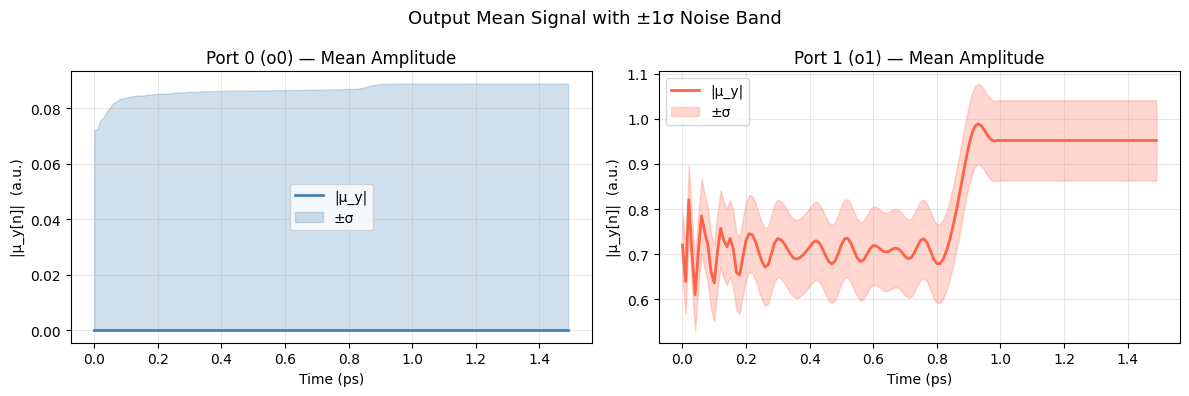

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ["steelblue", "tomato"]

for port in range(n_ports):
    ax = axes[port]
    mean_amp = np.asarray(jnp.abs(mu_y[:, port]))          # |µ_y[n]|
    std_y    = np.sqrt(np.maximum(
        np.real(np.asarray(Cy[:, :, port, port]).diagonal()), 0.0
    ))                                                       # σ_y[n]

    ax.plot(t_ps, mean_amp, color=colors[port], linewidth=2, label="|µ_y|")
    ax.fill_between(
        t_ps,
        np.maximum(mean_amp - std_y, 0),
        mean_amp + std_y,
        alpha=0.25, color=colors[port], label="±σ"
    )
    ax.set_title(f"Port {port} ({port_names[port]}) — Mean Amplitude")
    ax.set_xlabel("Time (ps)")
    ax.set_ylabel("|µ_y[n]|  (a.u.)")
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle("Output Mean Signal with ±1σ Noise Band", fontsize=13)
plt.tight_layout()
plt.show()

### 5b. Noise Variance Evolution

The diagonal $C_y[n, n, \text{port}, \text{port}]$ gives the instantaneous noise
power at each time step.  

For the input white noise ($C_x = \sigma^2 I$), the output variance at time $n$ equals:

$$
\sigma_y^2[n] = \sigma^2 \sum_{k=0}^{\min(n,\, K-1)} \|h[k]\|_F^2
$$

This accumulates as more of the impulse response taps contribute, then saturates
once $n \geq K-1$ — exactly the Parseval relation in the time domain.

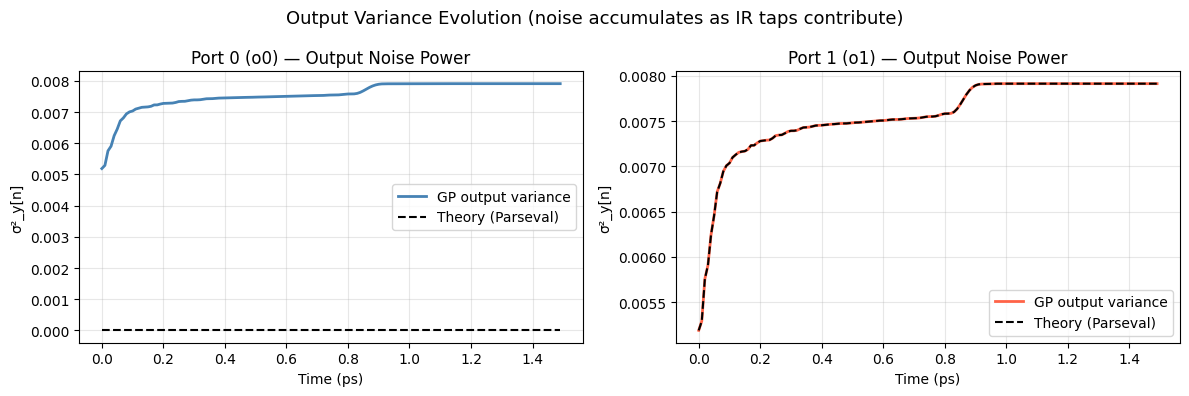

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Theoretical saturation: σ² × cumulative ‖h[:,port,0]‖²
cum_h_energy = sigma_sq * np.cumsum(np.abs(np.asarray(h_gp[:, :, 0])) ** 2, axis=0)  # (K, q)

for port in range(n_ports):
    ax = axes[port]

    # GP output variance (diagonal of Cy)
    var_out = np.real(np.asarray(Cy[:, :, port, port]).diagonal())
    ax.plot(t_ps, var_out, color=colors[port], linewidth=2, label="GP output variance")

    # Theoretical prediction (input from port 0 only)
    theory = np.pad(cum_h_energy[:, port], (0, T_sim - K_gp), constant_values=cum_h_energy[-1, port])
    ax.plot(t_ps, theory, "k--", linewidth=1.5, label="Theory (Parseval)")

    ax.set_title(f"Port {port} ({port_names[port]}) — Output Noise Power")
    ax.set_xlabel("Time (ps)")
    ax.set_ylabel("σ²_y[n]")
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle("Output Variance Evolution (noise accumulates as IR taps contribute)", fontsize=13)
plt.tight_layout()
plt.show()

### 5c. Output Covariance Matrix — Temporal Correlations

The off-diagonal blocks $C_y[n_1, n_2]$ quantify correlations **between different
time steps** in the output field.  

Even though the input noise was **white** (no temporal correlations), the ring
resonator acts as a bandpass filter and introduces **memory**: noise that entered
at time $n_2$ still influences the field at time $n_1 > n_2$ via the ring's
impulse response.  The correlation decays over the ring's photon lifetime.

Below we plot $\text{Re}\bigl(C_y[n_1, n_2, 1, 1]\bigr)$ — the temporal covariance
of the transmission port (port 1).  Compare it to the input covariance $C_x$,
which is diagonal by construction.

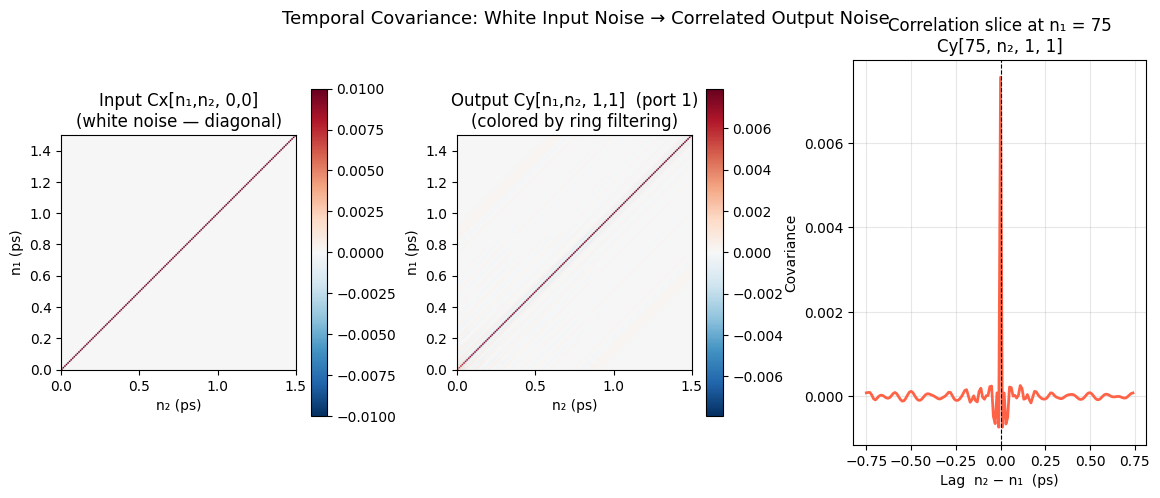

In [13]:
fig = plt.figure(figsize=(14, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# --- Input covariance (port 0, diagonal = white noise) ---
ax0  = fig.add_subplot(gs[0])
Cx00 = np.real(np.asarray(Cx[:, :, 0, 0]))
im0  = ax0.imshow(Cx00, cmap="RdBu_r", origin="lower",
                  extent=[0, T_sim*dt*1e12, 0, T_sim*dt*1e12],
                  vmin=-Cx00.max(), vmax=Cx00.max())
plt.colorbar(im0, ax=ax0, shrink=0.85)
ax0.set_title("Input Cx[n₁,n₂, 0,0]\n(white noise — diagonal)")
ax0.set_xlabel("n₂ (ps)")
ax0.set_ylabel("n₁ (ps)")

# --- Output covariance at port 1 ---
Cy11 = np.real(np.asarray(Cy[:, :, 1, 1]))
vmax = np.abs(Cy11).max()

ax1 = fig.add_subplot(gs[1])
im1 = ax1.imshow(Cy11, cmap="RdBu_r", origin="lower",
                 extent=[0, T_sim*dt*1e12, 0, T_sim*dt*1e12],
                 vmin=-vmax, vmax=vmax)
plt.colorbar(im1, ax=ax1, shrink=0.85)
ax1.set_title("Output Cy[n₁,n₂, 1,1]  (port 1)\n(colored by ring filtering)")
ax1.set_xlabel("n₂ (ps)")
ax1.set_ylabel("n₁ (ps)")

# --- Off-diagonal slice: correlation vs lag ---
ax2   = fig.add_subplot(gs[2])
n_ref = T_sim // 2
lag   = (np.arange(T_sim) - n_ref) * dt * 1e12
ax2.plot(lag, Cy11[n_ref, :], color="tomato", linewidth=2)
ax2.axvline(0, color="k", linewidth=0.8, linestyle="--")
ax2.set_title(f"Correlation slice at n₁ = {n_ref}\nCy[{n_ref}, n₂, 1, 1]")
ax2.set_xlabel("Lag  n₂ − n₁  (ps)")
ax2.set_ylabel("Covariance")
ax2.grid(True, alpha=0.3)

fig.suptitle("Temporal Covariance: White Input Noise → Correlated Output Noise", fontsize=13)
plt.show()

## 6. Summary

| Step | Module | Input | Output |
|---|---|---|---|
| Circuit | SAX | netlist + model params | S-matrix `(N_f, q, m)` |
| Vector fitting | `z_domain.vector_fitting_discrete` | S-matrix, frequency | poles, residues, feedthrough |
| State-space | `z_domain.state_space_discrete` | poles, residues, feedthrough | A, B, C, D |
| Impulse response | `z_domain.state_space_response_discrete` | A, B, C, D + impulse input | h `(K, q, m)` |
| GP simulation | `gaussian_process.gaussian_process_response` | h, µ_x, C_x | µ_y, C_y |

**Key insight:** the same impulse response $h$ that drives deterministic time-domain
simulations also governs how **noise statistics** propagate via the Papoulis equations.
White noise at the input becomes *spectrally colored*, correlated noise at the output —
the bandwidth of the ring resonator directly sets the correlation time of the output
fluctuations (visible as off-diagonal bands in the $C_y$ heatmap above).

This stochastic analysis is the intended backend for a Gaussian-process simulation
mode in Simphony, complementing the existing `sample_mode`, `block_mode`, and
`s_parameter` simulators.